In [2]:
import polars as pl
import seaborn as sns
from pathlib import Path
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick

sns.set_style('whitegrid')

In [3]:
results_path = Path('/projectnb/vkolagrp/bellitti/adrd-foundation-model/adrd_simplified_evaluation/results')

In [4]:
code_to_diag = {'PSY': 'Psychiatric conditions including schizophrenia, depression, bipolar disorder, anxiety and posttraumatic stress disorder (PSY)',
 'N/A':'Not applicable (no cognitive impairment)',
 'VD': 'Vascular brain injury or vascular dementia including stroke (VD)',
 'SEF': 'Systemic and environmental factors including infectious diseases (HIV included), metabolic, substance abuse / alcohol, medications, systemic disease and delirium (SEF)',
 'OTH': "Other (Multiple system atrophy, Essential tremor, Down syndrome, Huntington's disease, Prion disease, Traumatic brain injury, Normal-pressure hydrocephalus, Epilepsy, CNS neoplasm, etc)",
 'FTLD': 'Frontotemporal lobar degeneration and its variants, including primary progressive aphasia, corticobasal degeneration and progressive supranuclear palsy, and with or without amyotrophic lateral sclerosis (FTLD)',
 'AD': "Alzheimer's disease (AD)",
 'LBD': 'Lewy body disease (LBD)'}

diag_to_code = {v:k for k,v in code_to_diag.items()}

In [8]:
base = (
    pl.read_parquet(
        results_path
        / 'comparison_inc'
        / 'test_etpr'
        # / "2025-08-15T13:40:51-Qwen2.5-3B-Instruct"
        / "2025-08-15T10:20:12-Qwen2.5-7B-Instruct"
        / "test_etpr_output_extracted_answers_last.parquet"
    )
    .select("ID", "options", "ground_truth_text", "ground_truth", "prediction")
    .with_columns(
        pl.lit("Base").alias("model"), pl.row_index().over("ID").alias("attempt")
    )
)

# 3B
ours = (
    pl.read_parquet(
        results_path
        / 'comparison_inc'
        / 'test_etpr'
        / "2025-09-22T14:30:23-NACC-inc-os-sce"
        # / "2025-09-18T15:40:01-NACC_Inc-1000"
        # / "2025-09-18T17:42:36-NACC_Inc-sce-tanh-1000"
        / "test_etpr_output_extracted_answers_last.parquet"
    )
    .select("ID", "options", "ground_truth_text", "ground_truth", "prediction")
    .with_columns(
        pl.lit("Ours").alias("model"), pl.row_index().over("ID").alias("attempt")
    )
)


# 7B
# ours = (
#     pl.read_parquet(
#         results_path
#         / 'training_curve_inc/test_etpr/2025-09-29T17:15:50-NACC-7B-OS-1400'
#         / "test_etpr_output_extracted_answers_last.parquet"
#     )
#     .select("ID", "options", "ground_truth_text", "ground_truth", "prediction")
#     .with_columns(
#         pl.lit("Ours").alias("model"), pl.row_index().over("ID").alias("attempt")
#     )
# )

In [9]:
ans = pl.concat((base,ours),how='vertical').with_columns(
    pl.col('ground_truth_text').replace(diag_to_code).alias('diag_code'),
    (pl.col('ground_truth') == pl.col('prediction')).cast(pl.Int64).alias('correct')
)

In [10]:
base.filter(pl.col('attempt') == 0).select(
    pl.col('ground_truth_text').replace(diag_to_code).value_counts()
).unnest('ground_truth_text').sort('count',descending=True)

ground_truth_text,count
str,u32
"""AD""",3219
"""N/A""",951
"""FTLD""",759
"""LBD""",410
"""VD""",148
"""OTH""",93
"""SEF""",34
"""PSY""",12


In [11]:
recalls = (
    ans
    .group_by("diag_code", "model", "attempt")
    .agg(
        pl.col("correct").mean().alias("recall"),
    )
    # .group_by("diag_code", "model")
    # .agg(
    #     pl.col("recall").mean().alias("mean_recall"),
    #     pl.col("recall").var().alias("var_recall"),
    # )
    .sort("diag_code", "attempt", "model")
    .with_columns(
        (-pl.col("recall").diff(-1).over("diag_code","attempt")).alias("dR"),
    #     (pl.col("var_recall").sum().over("diag_code").sqrt()).alias("std_dR"),
    )
    .with_columns(
        (100 * pl.col("dR") / pl.col("recall")).alias("perc_inc"),
        # (100 * pl.col("dR").first() / pl.col("recall").abs().mean()).over('diag_code','attempt').alias("rpd")
        )
    .with_columns(
        ( pl.when(pl.col('dR').mean() > 0).then(pl.lit(1)).otherwise(-1).over('diag_code','model')).alias('sign')
    )
)

recalls

diag_code,model,attempt,recall,dR,perc_inc,sign
str,str,u32,f64,f64,f64,i32
"""AD""","""Base""",0,0.706741,-0.219944,-31.120879,-1
"""AD""","""Ours""",0,0.486797,null,null,-1
"""AD""","""Base""",1,0.695247,-0.201926,-29.043789,-1
"""AD""","""Ours""",1,0.493321,null,null,-1
"""AD""","""Base""",2,0.695558,-0.206275,-29.656096,-1
…,…,…,…,…,…,…
"""VD""","""Ours""",2,0.722973,null,null,-1
"""VD""","""Base""",3,0.763514,-0.0,-0.0,-1
"""VD""","""Ours""",3,0.763514,null,null,-1


In [12]:
# recalls = pl.concat(
#     (
#     recalls.with_columns(pl.lit("NACC").alias("Dataset")),
#     recalls.with_columns(pl.lit("OoD").alias("Dataset")),
#     )
# )

In [13]:
recalls

diag_code,model,attempt,recall,dR,perc_inc,sign
str,str,u32,f64,f64,f64,i32
"""AD""","""Base""",0,0.706741,-0.219944,-31.120879,-1
"""AD""","""Ours""",0,0.486797,null,null,-1
"""AD""","""Base""",1,0.695247,-0.201926,-29.043789,-1
"""AD""","""Ours""",1,0.493321,null,null,-1
"""AD""","""Base""",2,0.695558,-0.206275,-29.656096,-1
…,…,…,…,…,…,…
"""VD""","""Ours""",2,0.722973,null,null,-1
"""VD""","""Base""",3,0.763514,-0.0,-0.0,-1
"""VD""","""Ours""",3,0.763514,null,null,-1


In [14]:
order = [
    "LBD",
    "N/A",
    "FTLD",
    "VD",
    "AD",
    "OTH",
    "SEF",
    "PSY",
]

Text(0, 0.5, 'Percent improvement\nRecall over baseline')

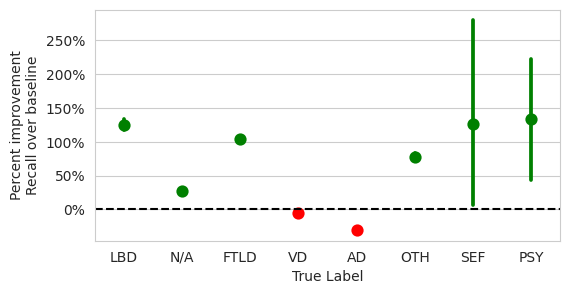

In [15]:
fig, ax = plt.subplots(1, 1, figsize=(6,3))

_df =  recalls.drop_nulls()

sns.pointplot(
    _df,
    x="diag_code",
    y="perc_inc",
    errorbar=('ci',95),
    ax=ax,
    order=order,
    # markersize=3,
    hue='sign',
    linestyles="none",
    legend=False,
    palette=sns.color_palette(['red','green'])

)

# sns.pointplot(
#     _df,
#     x="diag_code",
#     y="perc_inc",
#     errorbar=('ci',95),
#     ax=ax,
#     markers='o',
#  dodge=0.5,
#     order=order,
#     # markersize=3,
#     hue='sign',
#     linestyles="none",
#     legend=False,
#     palette=sns.color_palette(['red','green'])

# )


ax.axhline(0, linestyle="--", color="black")
ax.yaxis.set_major_formatter(mtick.PercentFormatter())

ax.set_xlabel("True Label")
ax.set_ylabel("Percent improvement\nRecall over baseline")

Text(0, 0.5, 'Recall score\nimprovement over baseline')

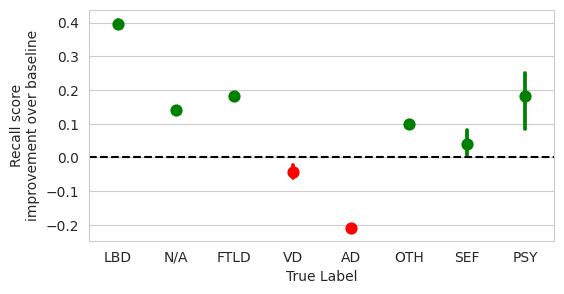

In [16]:
fig, ax = plt.subplots(1, 1, figsize=(6,3))

sns.pointplot(
    recalls.drop_nulls().sort("dR", descending=True),
    x="diag_code",
    y="dR",
    errorbar=('ci',95),
    ax=ax,
    linestyles="none",
    order=order,
    hue='sign',
    legend=False,
    palette=sns.color_palette(['red','green'])
)

ax.axhline(0, linestyle="--", color="black")

ax.set_xlabel("True Label")
ax.set_ylabel("Recall score\nimprovement over baseline")

(0.0, 1.0)

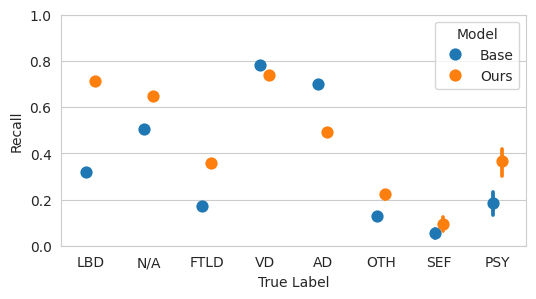

In [17]:
fig, ax = plt.subplots(1, 1, figsize=(6,3))

sns.pointplot(
    recalls,
    x="diag_code",
    y="recall",
    hue='model',
    errorbar=('ci',95),
    ax=ax,
    dodge=0.15,
    linestyles="none",
    order=order,
)

ax.set_xlabel("True Label")
ax.set_ylabel("Recall")
ax.legend(title='Model')

ax.set_ylim(0,1)